In [12]:
import pandas as pd

# Load the data
df = pd.read_csv('../data/raw/SPY_daily_yahoo_raw.csv', skiprows=[0,1,2], header=None, names=['Date','Adj Close','Close','High','Low','Open','Volume'], index_col=0, parse_dates=True, dtype={'Adj Close': float, 'Close': float, 'High': float, 'Low': float, 'Open': float, 'Volume': int})

# Compute 1-time-index linear increments
df['delta_P'] = df['Adj Close'].diff()

df = df.copy()
df['t'] = range(1, len(df) + 1)

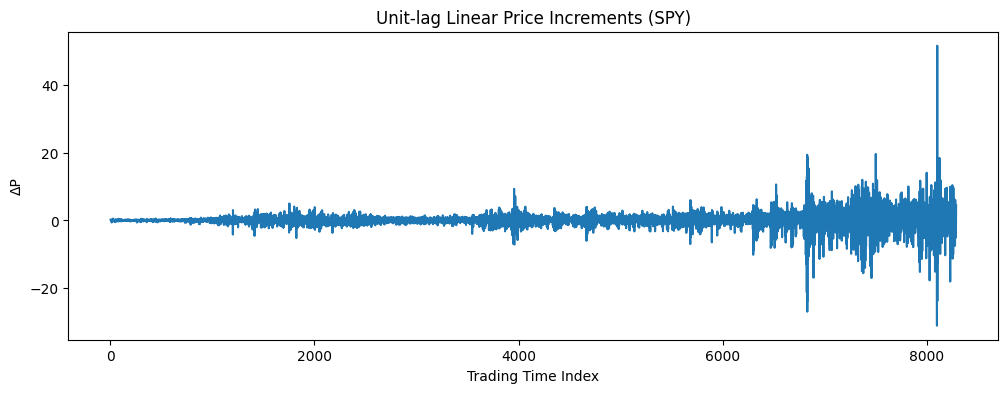

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(df['t'], df['delta_P'])
plt.title('Unit-lag Linear Price Increments (SPY)')
plt.xlabel('Trading Time Index')
plt.ylabel('ΔP')
plt.show()


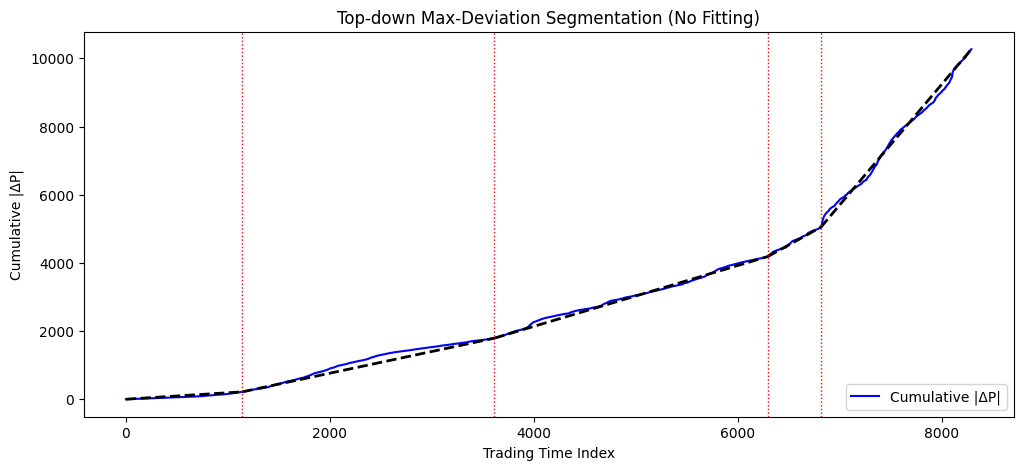

Segment 1: start=0, end=1142, slope=0.1902, N=1143
Segment 2: start=1142, end=3612, slope=0.6373, N=2471
Segment 3: start=3612, end=6292, slope=0.8934, N=2681
Segment 4: start=6292, end=6812, slope=1.6523, N=521
Segment 5: start=6812, end=8288, slope=3.5387, N=1477


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# cumulative absolute increments
cum_abs = np.cumsum(np.abs(df['delta_P'].dropna().values))
t = np.arange(len(cum_abs))

max_segments = 5  # keep number of breaks LOW

# initial segment
segments = [(0, len(cum_abs) - 1)]

while len(segments) < max_segments:
    max_err = -1
    best_split = None
    best_segment = None

    for start, end in segments:
        if end - start < 3:
            continue

        # straight line between endpoints (NO fitting)
        line = cum_abs[start] + (cum_abs[end] - cum_abs[start]) / (end - start) * (t[start:end+1] - start)
        err = np.abs(cum_abs[start:end+1] - line)

        idx = np.argmax(err)
        if err[idx] > max_err:
            max_err = err[idx]
            best_split = start + idx
            best_segment = (start, end)

    if best_segment is None:
        break

    segments.remove(best_segment)
    segments.append((best_segment[0], best_split))
    segments.append((best_split, best_segment[1]))

segments = sorted(segments, key=lambda x: x[0])

# ---------------- Plot ----------------
plt.figure(figsize=(12,5))
plt.plot(t, cum_abs, color='blue', label='Cumulative |ΔP|')

# plot straight segments
for start, end in segments:
    plt.plot(
        t[start:end+1],
        cum_abs[start] + (cum_abs[end] - cum_abs[start]) / (end - start) * (t[start:end+1] - start),
        color='black',
        linestyle='dashed',
        linewidth=2
    )

# vertical break lines
for _, end in segments[:-1]:
    plt.axvline(end, color='red', linestyle='dotted', linewidth=1)

plt.xlabel('Trading Time Index')
plt.ylabel('Cumulative |ΔP|')
plt.title('Top-down Max-Deviation Segmentation (No Fitting)')
plt.legend()
plt.show()

# segment summary
for i, (start, end) in enumerate(segments):
    slope = (cum_abs[end] - cum_abs[start]) / (end - start)
    print(f"Segment {i+1}: start={start}, end={end}, slope={slope:.4f}, N={end-start+1}")


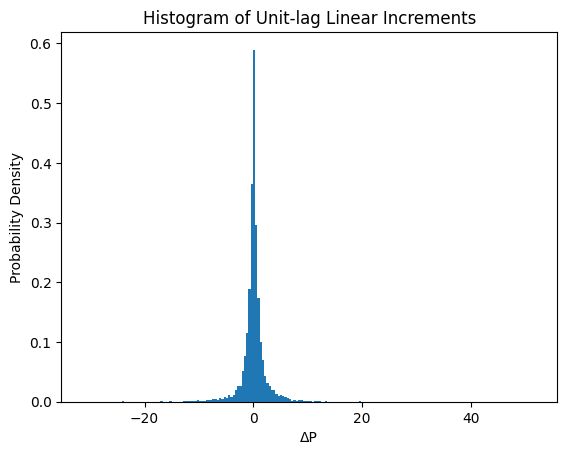

In [15]:
plt.figure()
plt.hist(df['delta_P'].dropna(), bins=200, density=True)
plt.title('Histogram of Unit-lag Linear Increments')
plt.xlabel('ΔP')
plt.ylabel('Probability Density')
plt.show()
# Plot the linear increments